# EDA: Dataset Overview

**Phase 1 — EDA & Data Understanding**

Systematic data profiling of the WiDS 2026 Wildfire Time-to-Threat dataset.

**Goals:**
- Column-by-column analysis: distributions, cardinality, nulls
- Target variable analysis (`time_to_hit_hours` + `event`)
- Correlation heatmap
- Missing data patterns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 80)
sns.set_theme(style="whitegrid", palette="muted")

FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name: str, fig=None) -> None:
    """Save current figure to reports/figures/."""
    if fig is None:
        fig = plt.gcf()
    fig.savefig(FIGURES_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    print(f"Saved: {FIGURES_DIR / name}.png")

## 1. Load Data

In [2]:
train = pd.read_csv("../data/raw/train.csv")
test = pd.read_csv("../data/raw/test.csv")
sample_sub = pd.read_csv("../data/raw/sample_submission.csv")
metadata = pd.read_csv("../data/raw/metaData.csv")

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")
print(f"Sample sub:  {sample_sub.shape}")
print(f"Metadata:    {metadata.shape}")

Train shape: (221, 37)
Test shape:  (95, 35)
Sample sub:  (95, 5)
Metadata:    (37, 6)


In [3]:
# Metadata — column descriptions
metadata

,column,type,category,description,units,range
0,event_id,identifier,identifier,"Anonymized fire event identifier (stable random remap, no temporal meaning)",NaN,NaN
1,time_to_hit_hours,target,target,Time from t0+5h until fire comes within 5km of evac zone (hours). For censor...,hours,"[0, 72]"
2,event,target,target,"Event indicator: 1 if fire hit within 72h, 0 if censored (never hit)",NaN,NaN
3,num_perimeters_0_5h,feature,temporal_coverage,Number of perimeters within first 5 hours,NaN,NaN
4,dt_first_last_0_5h,feature,temporal_coverage,Time span between first and last perimeter (hours),NaN,NaN
5,low_temporal_resolution_0_5h,feature,temporal_coverage,"Flag: 1 if dt < 0.5h or only 1 perimeter, else 0",NaN,NaN
6,area_first_ha,feature,growth,Initial fire area at t0 (hectares),NaN,NaN
7,area_growth_abs_0_5h,feature,growth,Feature from growth category,NaN,NaN
8,area_growth_rel_0_5h,feature,growth,Feature from growth category,NaN,NaN
9,area_growth_rate_ha_per_h,feature,growth,Area growth rate (hectares per hour),NaN,NaN


In [4]:
# Submission format
print("Submission columns:", sample_sub.columns.tolist())
print("\nTarget: predict prob_12h, prob_24h, prob_48h, prob_72h")
print("These are P(fire hits within T hours) for T = 12, 24, 48, 72")
sample_sub.head()

Submission columns: ['event_id', 'prob_12h', 'prob_24h', 'prob_48h', 'prob_72h']

Target: predict prob_12h, prob_24h, prob_48h, prob_72h
These are P(fire hits within T hours) for T = 12, 24, 48, 72


,event_id,prob_12h,prob_24h,prob_48h,prob_72h
0,10662602,0.5,0.5,0.5,0.5
1,13353600,0.5,0.5,0.5,0.5
2,13942327,0.5,0.5,0.5,0.5
3,16112781,0.5,0.5,0.5,0.5
4,17132808,0.5,0.5,0.5,0.5


## 2. Dataset Overview

In [5]:
# Basic info
print("=" * 60)
print("TRAIN DATASET")
print("=" * 60)
print(f"Rows: {train.shape[0]}")
print(f"Columns: {train.shape[1]}")
print(f"\nColumn types:")
print(train.dtypes.value_counts())
print(f"\nNull values: {train.isnull().sum().sum()} total")
print(f"Duplicate rows: {train.duplicated().sum()}")

TRAIN DATASET
Rows: 221
Columns: 37

Column types:
float64    30
int64       7
Name: count, dtype: int64

Null values: 0 total
Duplicate rows: 0


In [6]:
# Columns missing in test vs train
train_only = set(train.columns) - set(test.columns)
test_only = set(test.columns) - set(train.columns)
print(f"Columns in train but NOT test: {train_only}")
print(f"Columns in test but NOT train: {test_only}")

Columns in train but NOT test: {'event', 'time_to_hit_hours'}
Columns in test but NOT train: set()


In [7]:
# Summary statistics per column
def column_summary(df: pd.DataFrame, name: str = "train") -> pd.DataFrame:
    """Generate a per-column summary."""
    summary = pd.DataFrame({
        "dtype": df.dtypes,
        "nulls": df.isnull().sum(),
        "null_pct": (df.isnull().sum() / len(df) * 100).round(2),
        "unique": df.nunique(),
        "min": df.min(numeric_only=False),
        "max": df.max(numeric_only=False),
        "mean": df.select_dtypes(include="number").mean(),
        "std": df.select_dtypes(include="number").std(),
        "median": df.select_dtypes(include="number").median(),
    })
    return summary

train_summary = column_summary(train)
train_summary

,dtype,nulls,null_pct,unique,min,max,mean,std,median
event_id,int64,0,0.0,221,1.089246e+07,9.933973e+07,5.384397e+07,2.507456e+07,5.244094e+07
num_perimeters_0_5h,int64,0,0.0,12,1.000000e+00,1.700000e+01,2.063348e+00,2.578859e+00,1.000000e+00
dt_first_last_0_5h,float64,0,0.0,62,0.000000e+00,4.994457e+00,9.798688e-01,1.738052e+00,0.000000e+00
low_temporal_resolution_0_5h,int64,0,0.0,2,0.000000e+00,1.000000e+00,7.285068e-01,4.457395e-01,1.000000e+00
area_first_ha,float64,0,0.0,221,3.752484e-02,1.194239e+04,6.191316e+02,1.447724e+03,1.101493e+02
area_growth_abs_0_5h,float64,0,0.0,26,-2.156175e-05,2.508041e+03,2.633240e+01,1.874370e+02,0.000000e+00
area_growth_rel_0_5h,float64,0,0.0,26,-1.437844e-07,1.788970e+01,1.789087e-01,1.302001e+00,0.000000e+00
area_growth_rate_ha_per_h,float64,0,0.0,26,-5.292846e-06,5.204430e+02,6.167128e+00,4.046737e+01,0.000000e+00
log1p_area_first,float64,0,0.0,221,3.683791e-02,9.387933e+00,4.683276e+00,2.083529e+00,4.710874e+00
log1p_growth,float64,0,0.0,25,0.000000e+00,7.827656e+00,3.893465e-01,1.340348e+00,0.000000e+00


## 3. Target Variable Analysis

The dataset is framed as **survival analysis**:
- `time_to_hit_hours`: time from t0+5h until fire comes within 5km of evacuation zone (0–72h)
- `event`: 1 = fire hit within 72h, 0 = censored (never hit)

Submission requires: `P(fire hits within T)` for T = 12, 24, 48, 72 hours.

Saved: ..\reports\figures\target_distribution.png


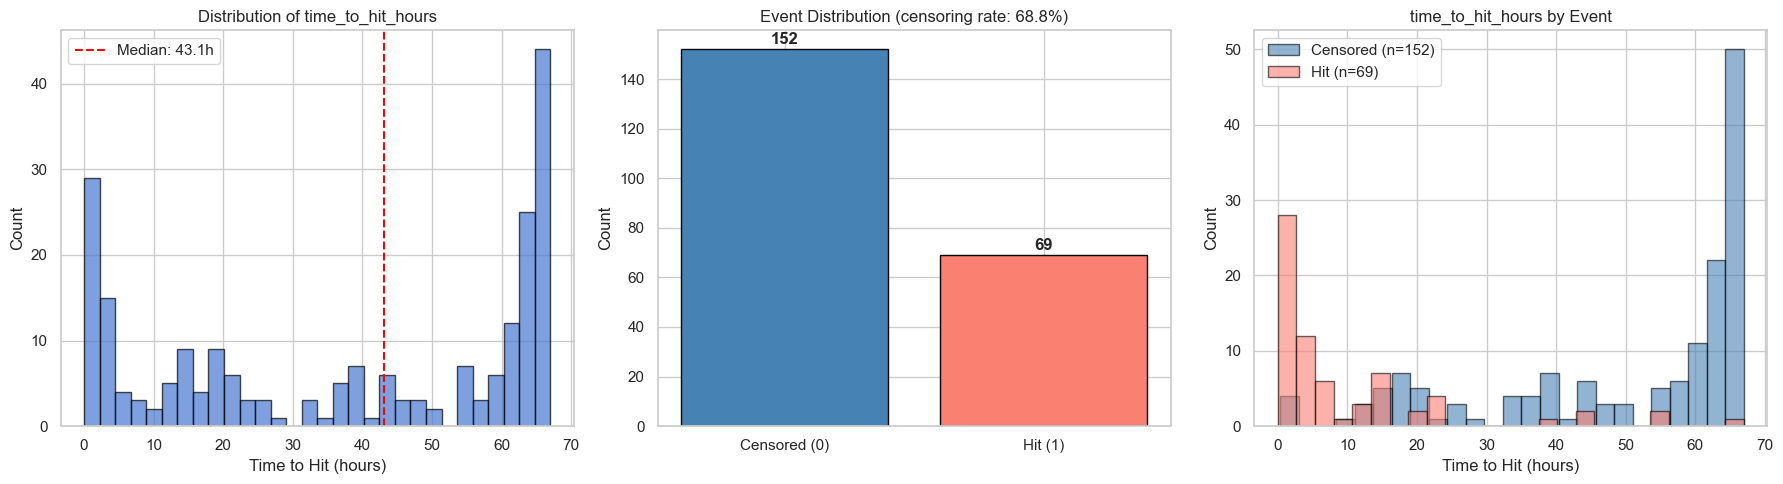

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution of time_to_hit_hours
axes[0].hist(train["time_to_hit_hours"], bins=30, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Time to Hit (hours)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of time_to_hit_hours")
axes[0].axvline(train["time_to_hit_hours"].median(), color="red", ls="--", label=f"Median: {train['time_to_hit_hours'].median():.1f}h")
axes[0].legend()

# Event distribution (censoring)
event_counts = train["event"].value_counts()
axes[1].bar(["Censored (0)", "Hit (1)"], event_counts.values, color=["steelblue", "salmon"], edgecolor="black")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Event Distribution (censoring rate: {(train['event']==0).mean():.1%})")
for i, v in enumerate(event_counts.values):
    axes[1].text(i, v + 2, str(v), ha="center", fontweight="bold")

# time_to_hit by event
for ev, color, label in [(0, "steelblue", "Censored"), (1, "salmon", "Hit")]:
    subset = train[train["event"] == ev]["time_to_hit_hours"]
    axes[2].hist(subset, bins=25, alpha=0.6, color=color, label=f"{label} (n={len(subset)})", edgecolor="black")
axes[2].set_xlabel("Time to Hit (hours)")
axes[2].set_ylabel("Count")
axes[2].set_title("time_to_hit_hours by Event")
axes[2].legend()

plt.tight_layout()
save_fig("target_distribution")
plt.show()

In [9]:
# Target statistics
print("=== time_to_hit_hours ===")
print(f"Min:    {train['time_to_hit_hours'].min():.4f}")
print(f"Max:    {train['time_to_hit_hours'].max():.4f}")
print(f"Mean:   {train['time_to_hit_hours'].mean():.4f}")
print(f"Median: {train['time_to_hit_hours'].median():.4f}")
print(f"Std:    {train['time_to_hit_hours'].std():.4f}")
print(f"\n=== event ===")
print(f"Hit (1):      {(train['event']==1).sum()} ({(train['event']==1).mean():.1%})")
print(f"Censored (0): {(train['event']==0).sum()} ({(train['event']==0).mean():.1%})")
print(f"\n=== Submission horizons ===")
for h in [12, 24, 48, 72]:
    hit_within = ((train["time_to_hit_hours"] <= h) & (train["event"] == 1)).sum()
    print(f"  Hit within {h:2d}h: {hit_within} ({hit_within/len(train):.1%})")

=== time_to_hit_hours ===
Min:    0.0012
Max:    66.9945
Mean:   37.5676
Median: 43.1098
Std:    25.9024

=== event ===
Hit (1):      69 (31.2%)
Censored (0): 152 (68.8%)

=== Submission horizons ===
  Hit within 12h: 49 (22.2%)
  Hit within 24h: 63 (28.5%)
  Hit within 48h: 66 (29.9%)
  Hit within 72h: 69 (31.2%)


## 4. Feature Distributions

Feature groups from metadata:
- **temporal_coverage** (3): perimeters, time span, resolution flag
- **growth** (10): area, growth rates, radial growth
- **centroid_kinematics** (5): displacement, speed, bearing
- **distance** (9): distance to evacuation zone, closing speed
- **directionality** (4): alignment, cross/along track
- **temporal_metadata** (3): hour, day of week, month

In [10]:
# Feature columns (exclude ID and targets)
feature_cols = [c for c in train.columns if c not in ["event_id", "time_to_hit_hours", "event"]]

# Group by metadata category
meta_dict = dict(zip(metadata["column"], metadata["category"]))
groups = {}
for col in feature_cols:
    cat = meta_dict.get(col, "unknown")
    groups.setdefault(cat, []).append(col)

for group, cols in groups.items():
    print(f"{group}: {cols}")

temporal_coverage: ['num_perimeters_0_5h', 'dt_first_last_0_5h', 'low_temporal_resolution_0_5h']
growth: ['area_first_ha', 'area_growth_abs_0_5h', 'area_growth_rel_0_5h', 'area_growth_rate_ha_per_h', 'log1p_area_first', 'log1p_growth', 'log_area_ratio_0_5h', 'relative_growth_0_5h', 'radial_growth_m', 'radial_growth_rate_m_per_h']
centroid_kinematics: ['centroid_displacement_m', 'centroid_speed_m_per_h', 'spread_bearing_deg', 'spread_bearing_sin', 'spread_bearing_cos']
distance: ['dist_min_ci_0_5h', 'dist_std_ci_0_5h', 'dist_change_ci_0_5h', 'dist_slope_ci_0_5h', 'closing_speed_m_per_h', 'closing_speed_abs_m_per_h', 'projected_advance_m', 'dist_accel_m_per_h2', 'dist_fit_r2_0_5h']
directionality: ['alignment_cos', 'alignment_abs', 'cross_track_component', 'along_track_speed']
temporal_metadata: ['event_start_hour', 'event_start_dayofweek', 'event_start_month']


Saved: ..\reports\figures\distributions_temporal_coverage.png


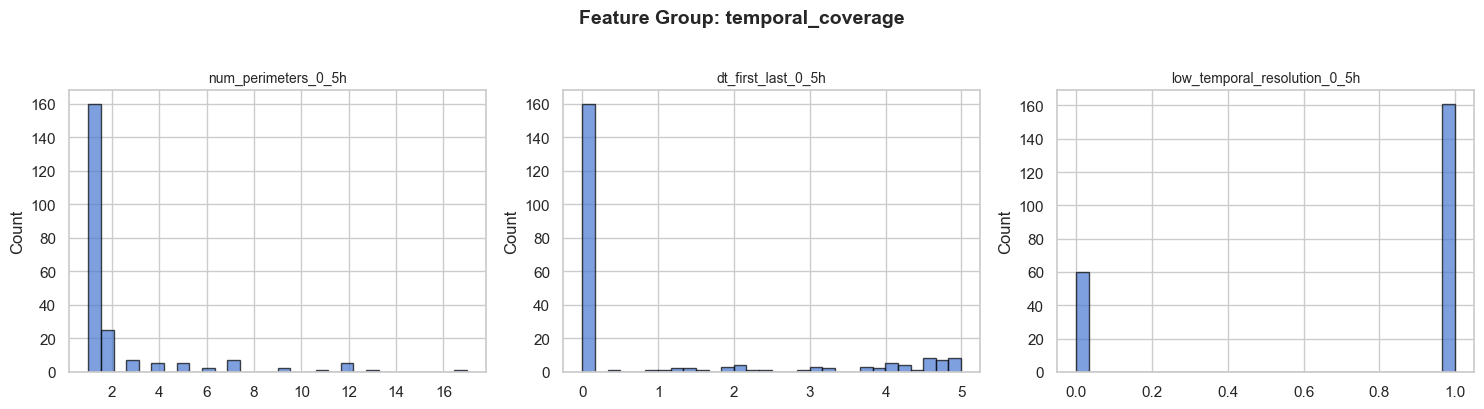

Saved: ..\reports\figures\distributions_growth.png


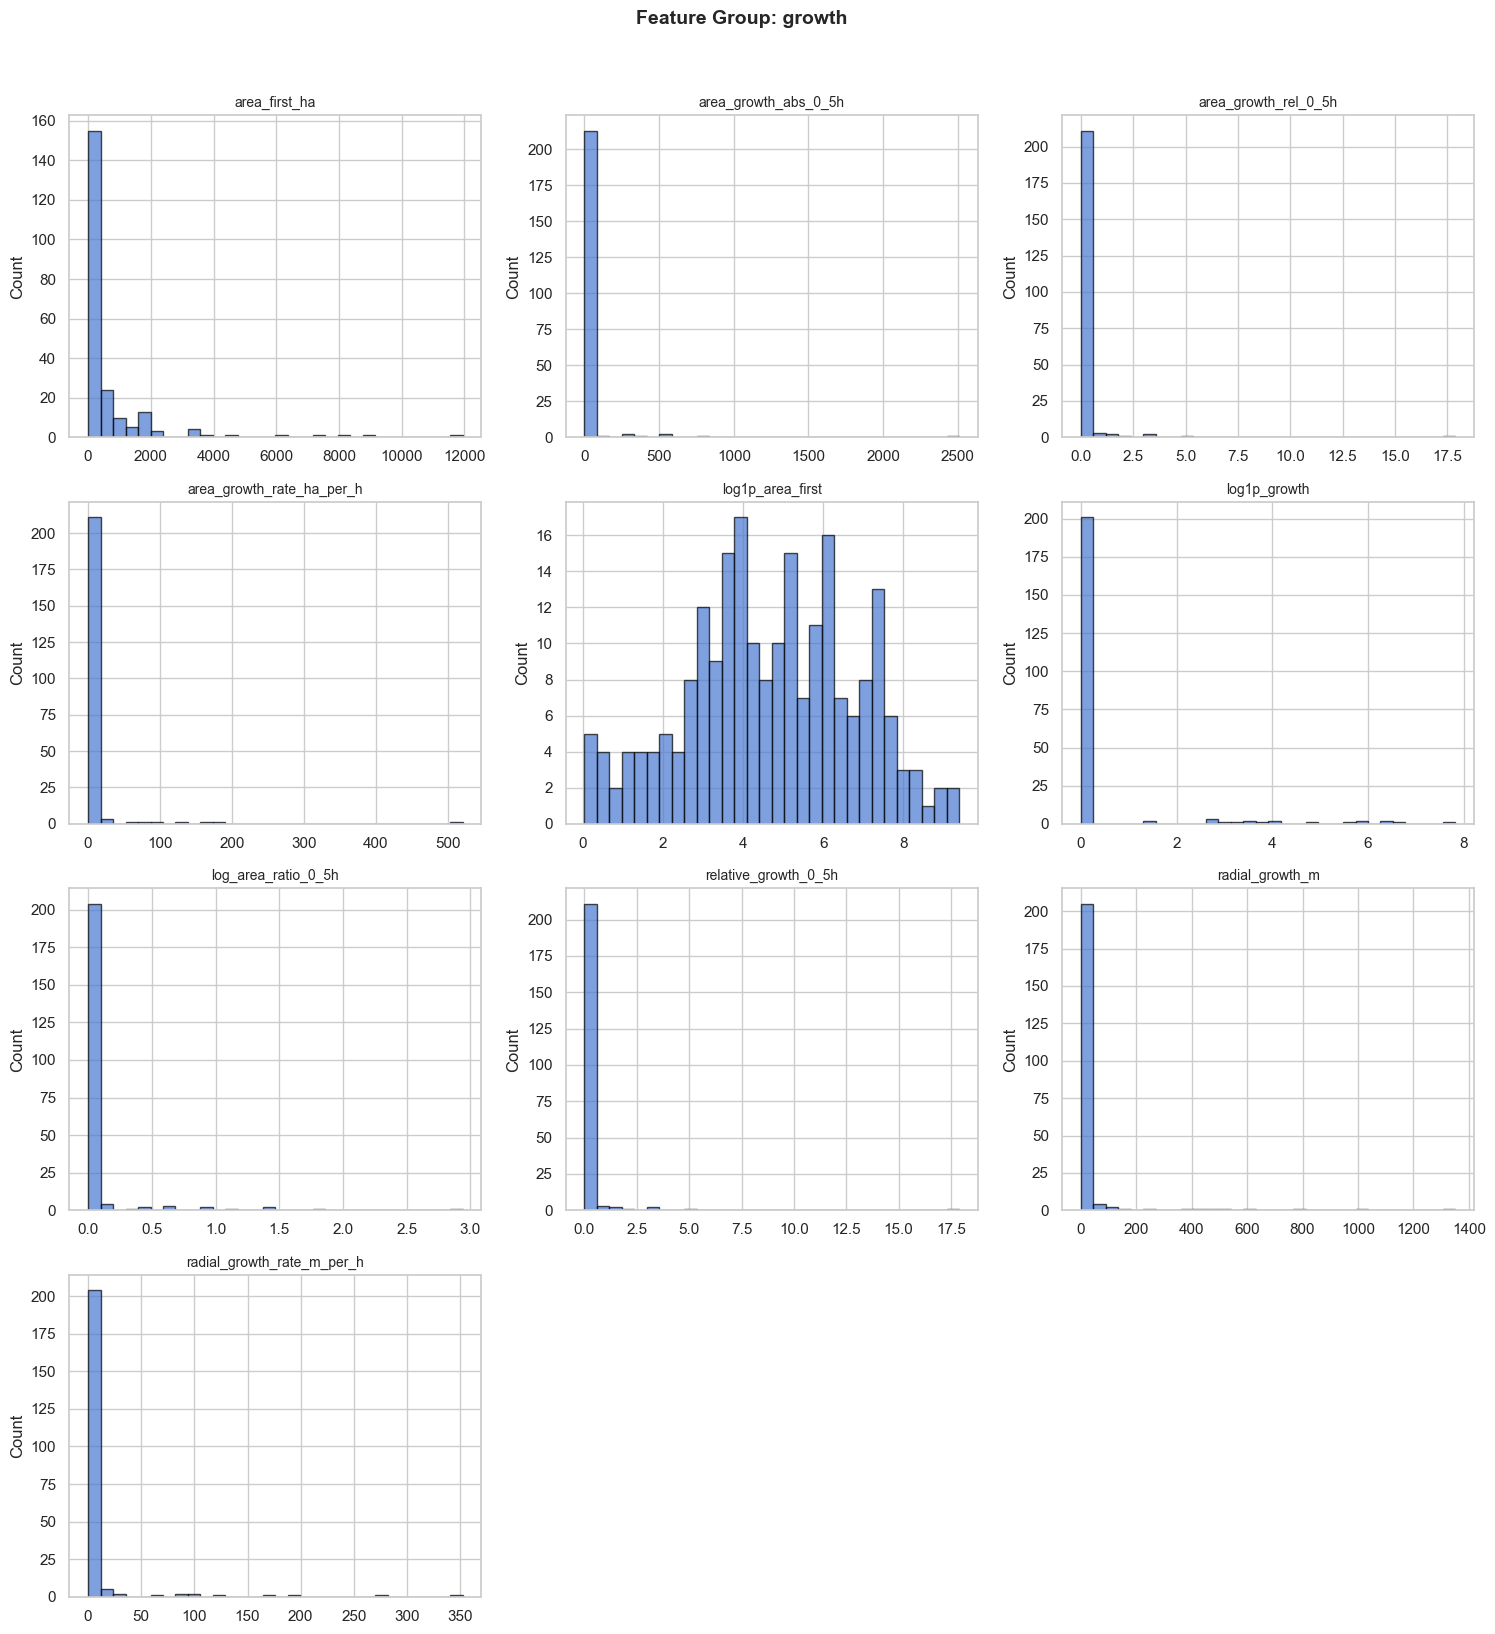

Saved: ..\reports\figures\distributions_centroid_kinematics.png


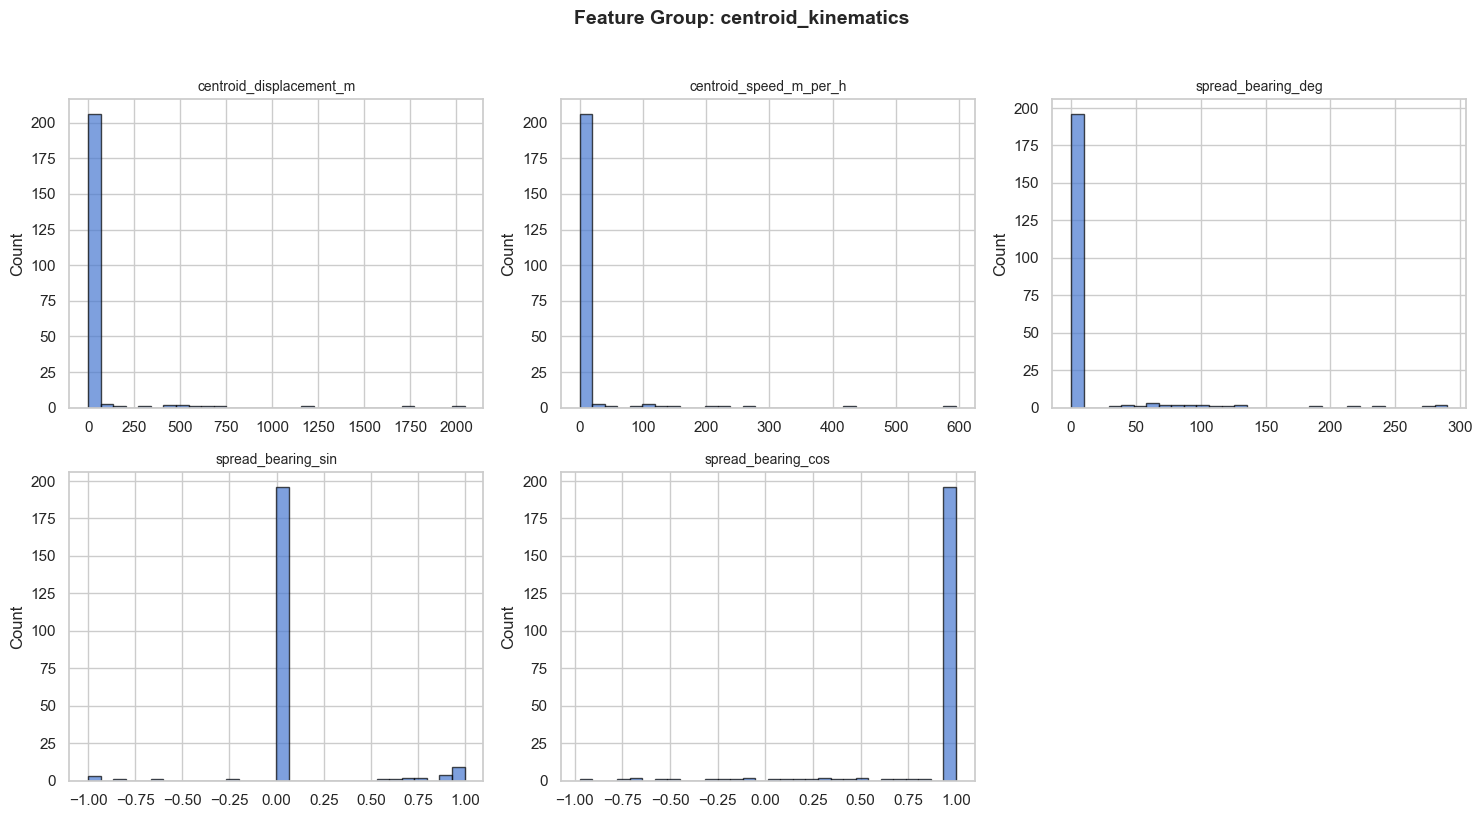

Saved: ..\reports\figures\distributions_distance.png


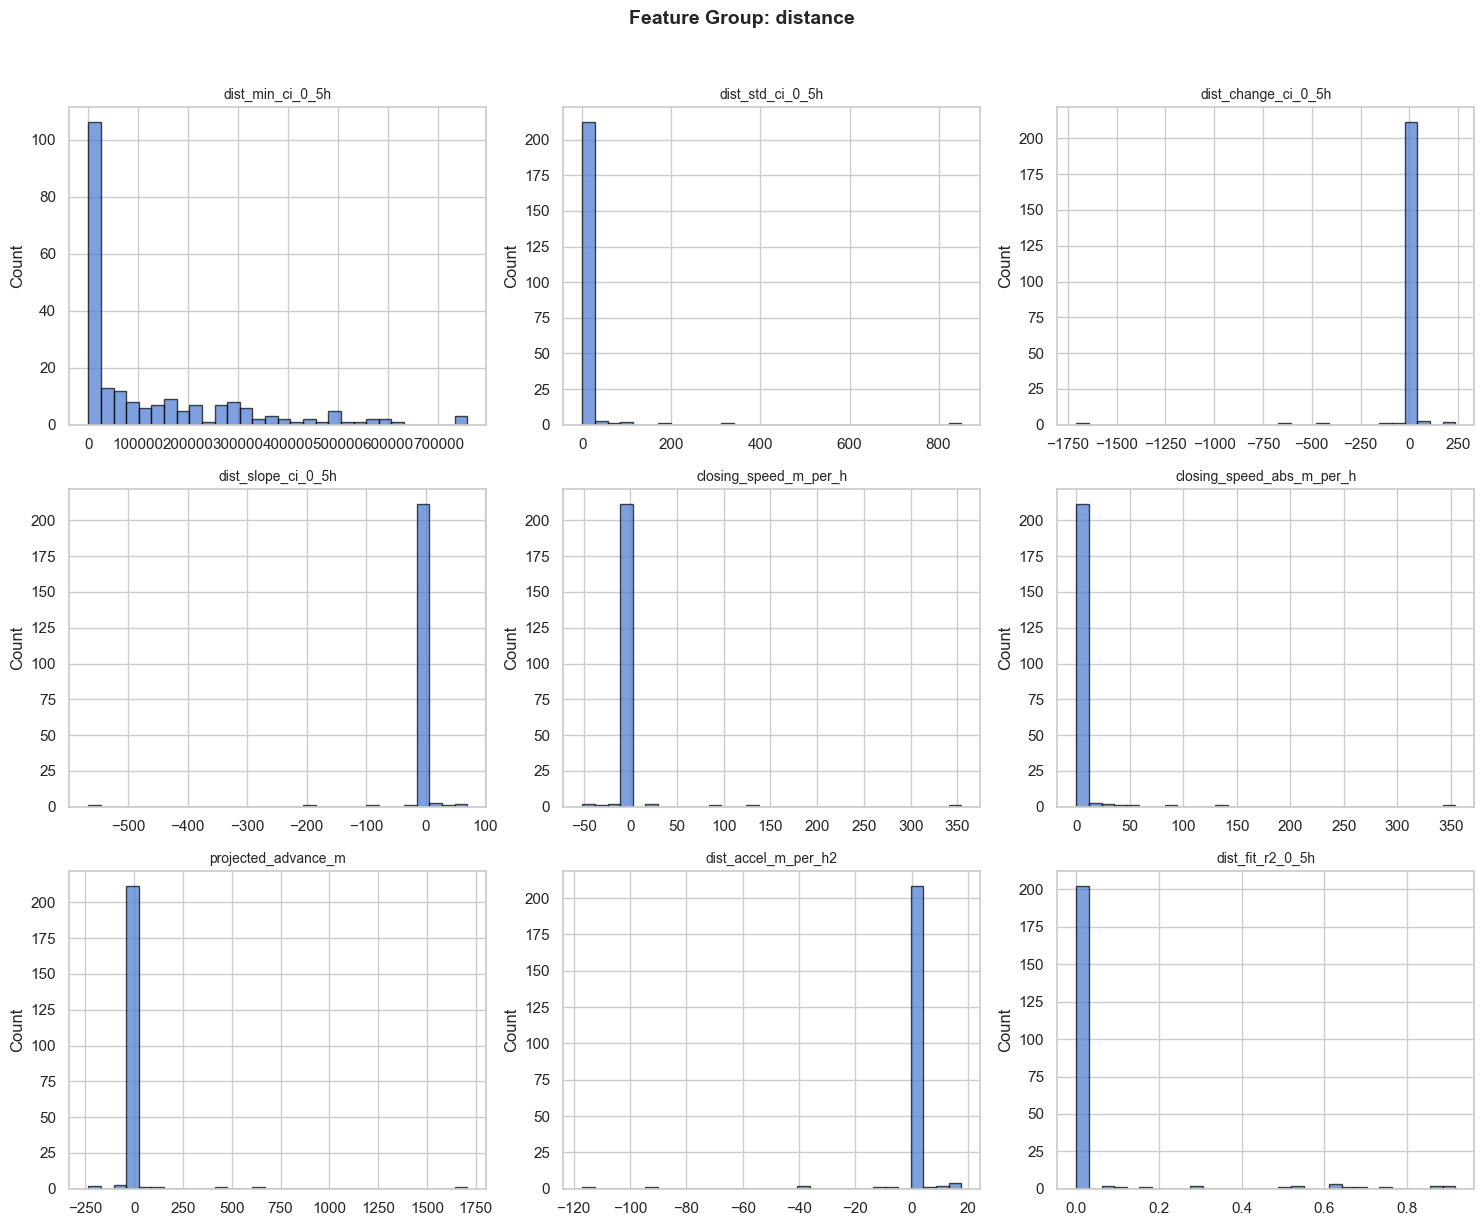

Saved: ..\reports\figures\distributions_directionality.png


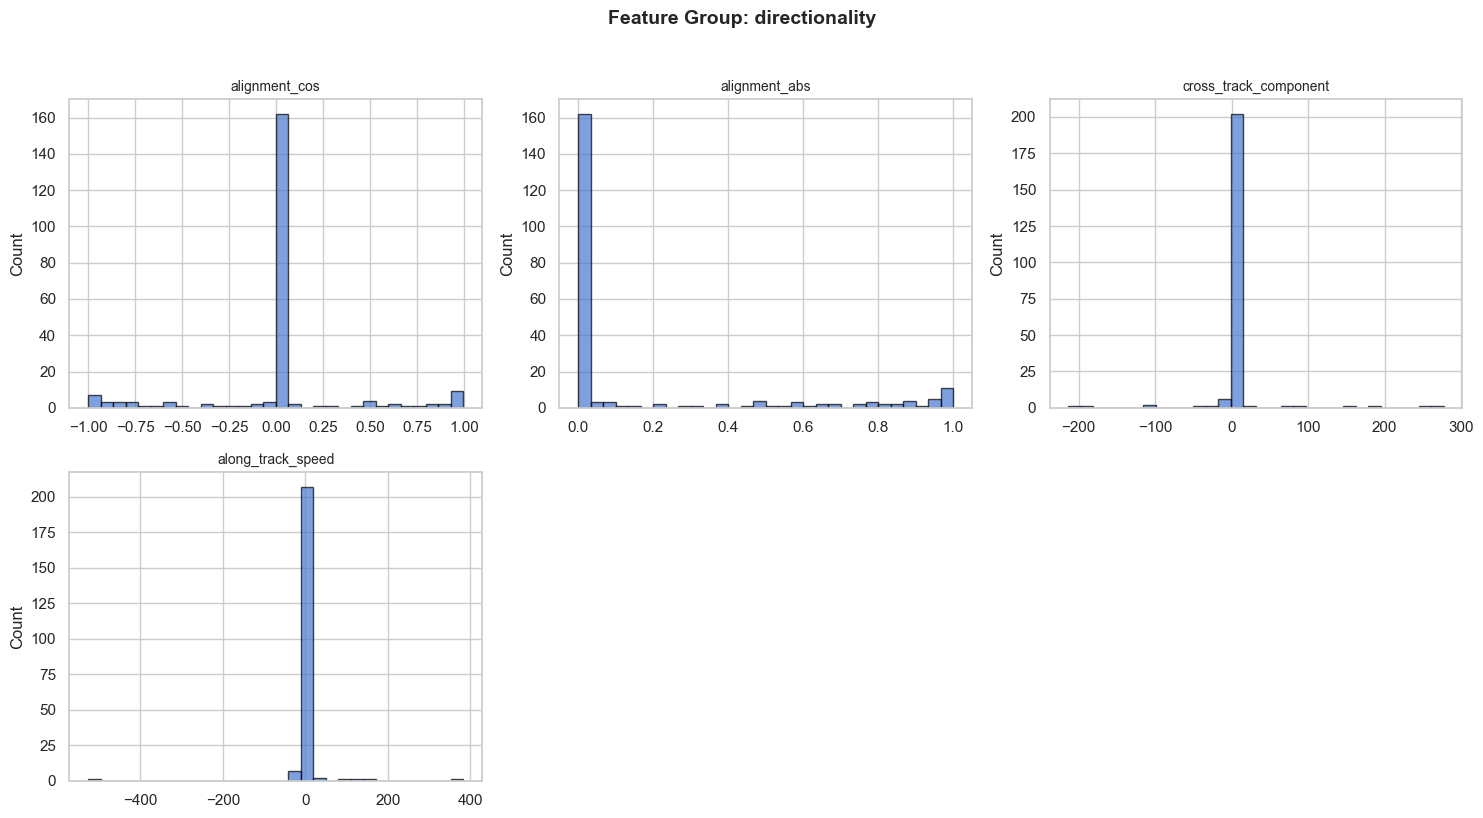

Saved: ..\reports\figures\distributions_temporal_metadata.png


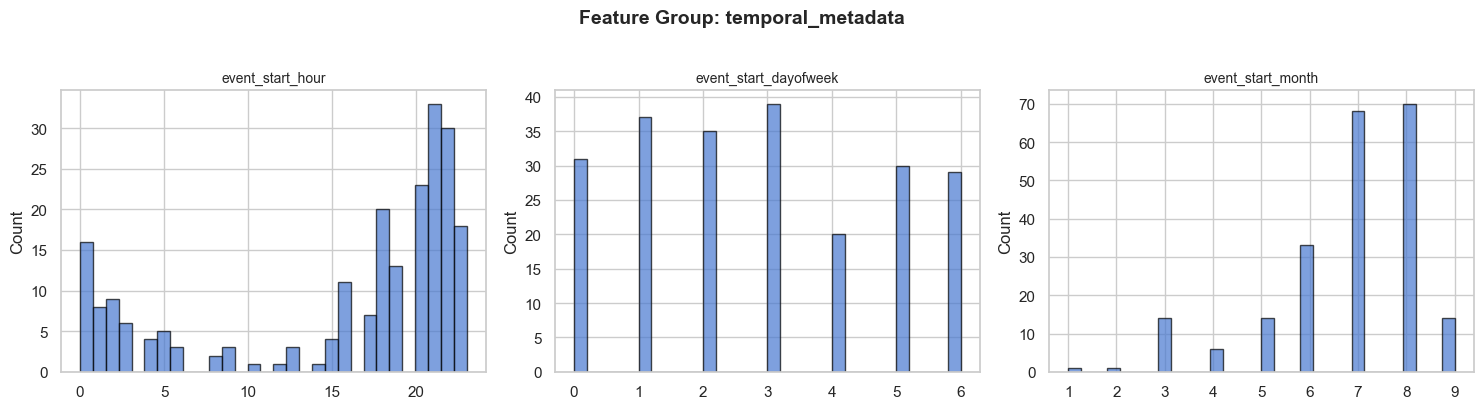

In [11]:
# Histograms for all features grouped by category
for group_name, cols in groups.items():
    n = len(cols)
    ncols_plot = min(n, 3)
    nrows_plot = (n + ncols_plot - 1) // ncols_plot
    fig, axes = plt.subplots(nrows_plot, ncols_plot, figsize=(5 * ncols_plot, 4 * nrows_plot))
    if nrows_plot * ncols_plot == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]
        train[col].hist(bins=30, ax=ax, edgecolor="black", alpha=0.7)
        ax.set_title(col, fontsize=10)
        ax.set_ylabel("Count")

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"Feature Group: {group_name}", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    save_fig(f"distributions_{group_name}")
    plt.show()

=== Percentage of zero values per feature ===
closing_speed_abs_m_per_h       0.918552
closing_speed_m_per_h           0.918552
projected_advance_m             0.918552
dist_change_ci_0_5h             0.918552
dist_fit_r2_0_5h                0.914027
dist_std_ci_0_5h                0.914027
log1p_growth                    0.891403
spread_bearing_sin              0.886878
centroid_displacement_m         0.886878
area_growth_rel_0_5h            0.886878
centroid_speed_m_per_h          0.886878
spread_bearing_deg              0.886878
area_growth_rate_ha_per_h       0.886878
area_growth_abs_0_5h            0.886878
log_area_ratio_0_5h             0.886878
radial_growth_rate_m_per_h      0.886878
radial_growth_m                 0.886878
relative_growth_0_5h            0.886878
cross_track_component           0.886878
along_track_speed               0.886878
dist_accel_m_per_h2             0.841629
dist_slope_ci_0_5h              0.764706
alignment_abs                   0.723982
dt_first_la

Saved: ..\reports\figures\feature_sparsity.png


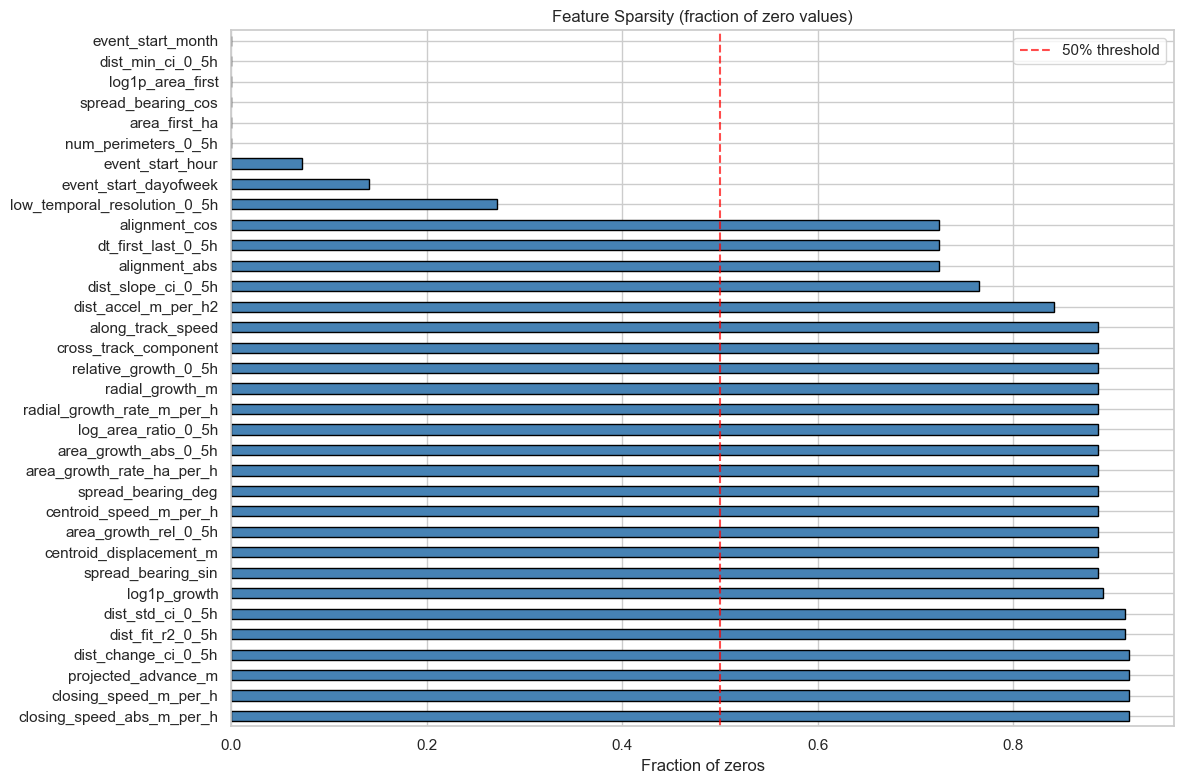

In [12]:
# Sparsity analysis — many features have lots of zeros
zero_pct = (train[feature_cols] == 0).mean().sort_values(ascending=False)
print("=== Percentage of zero values per feature ===")
print(zero_pct.to_string())

fig, ax = plt.subplots(figsize=(12, 8))
zero_pct.plot(kind="barh", ax=ax, color="steelblue", edgecolor="black")
ax.set_xlabel("Fraction of zeros")
ax.set_title("Feature Sparsity (fraction of zero values)")
ax.axvline(0.5, color="red", ls="--", alpha=0.7, label="50% threshold")
ax.legend()
plt.tight_layout()
save_fig("feature_sparsity")
plt.show()

## 5. Correlation Analysis

Saved: ..\reports\figures\correlation_heatmap.png


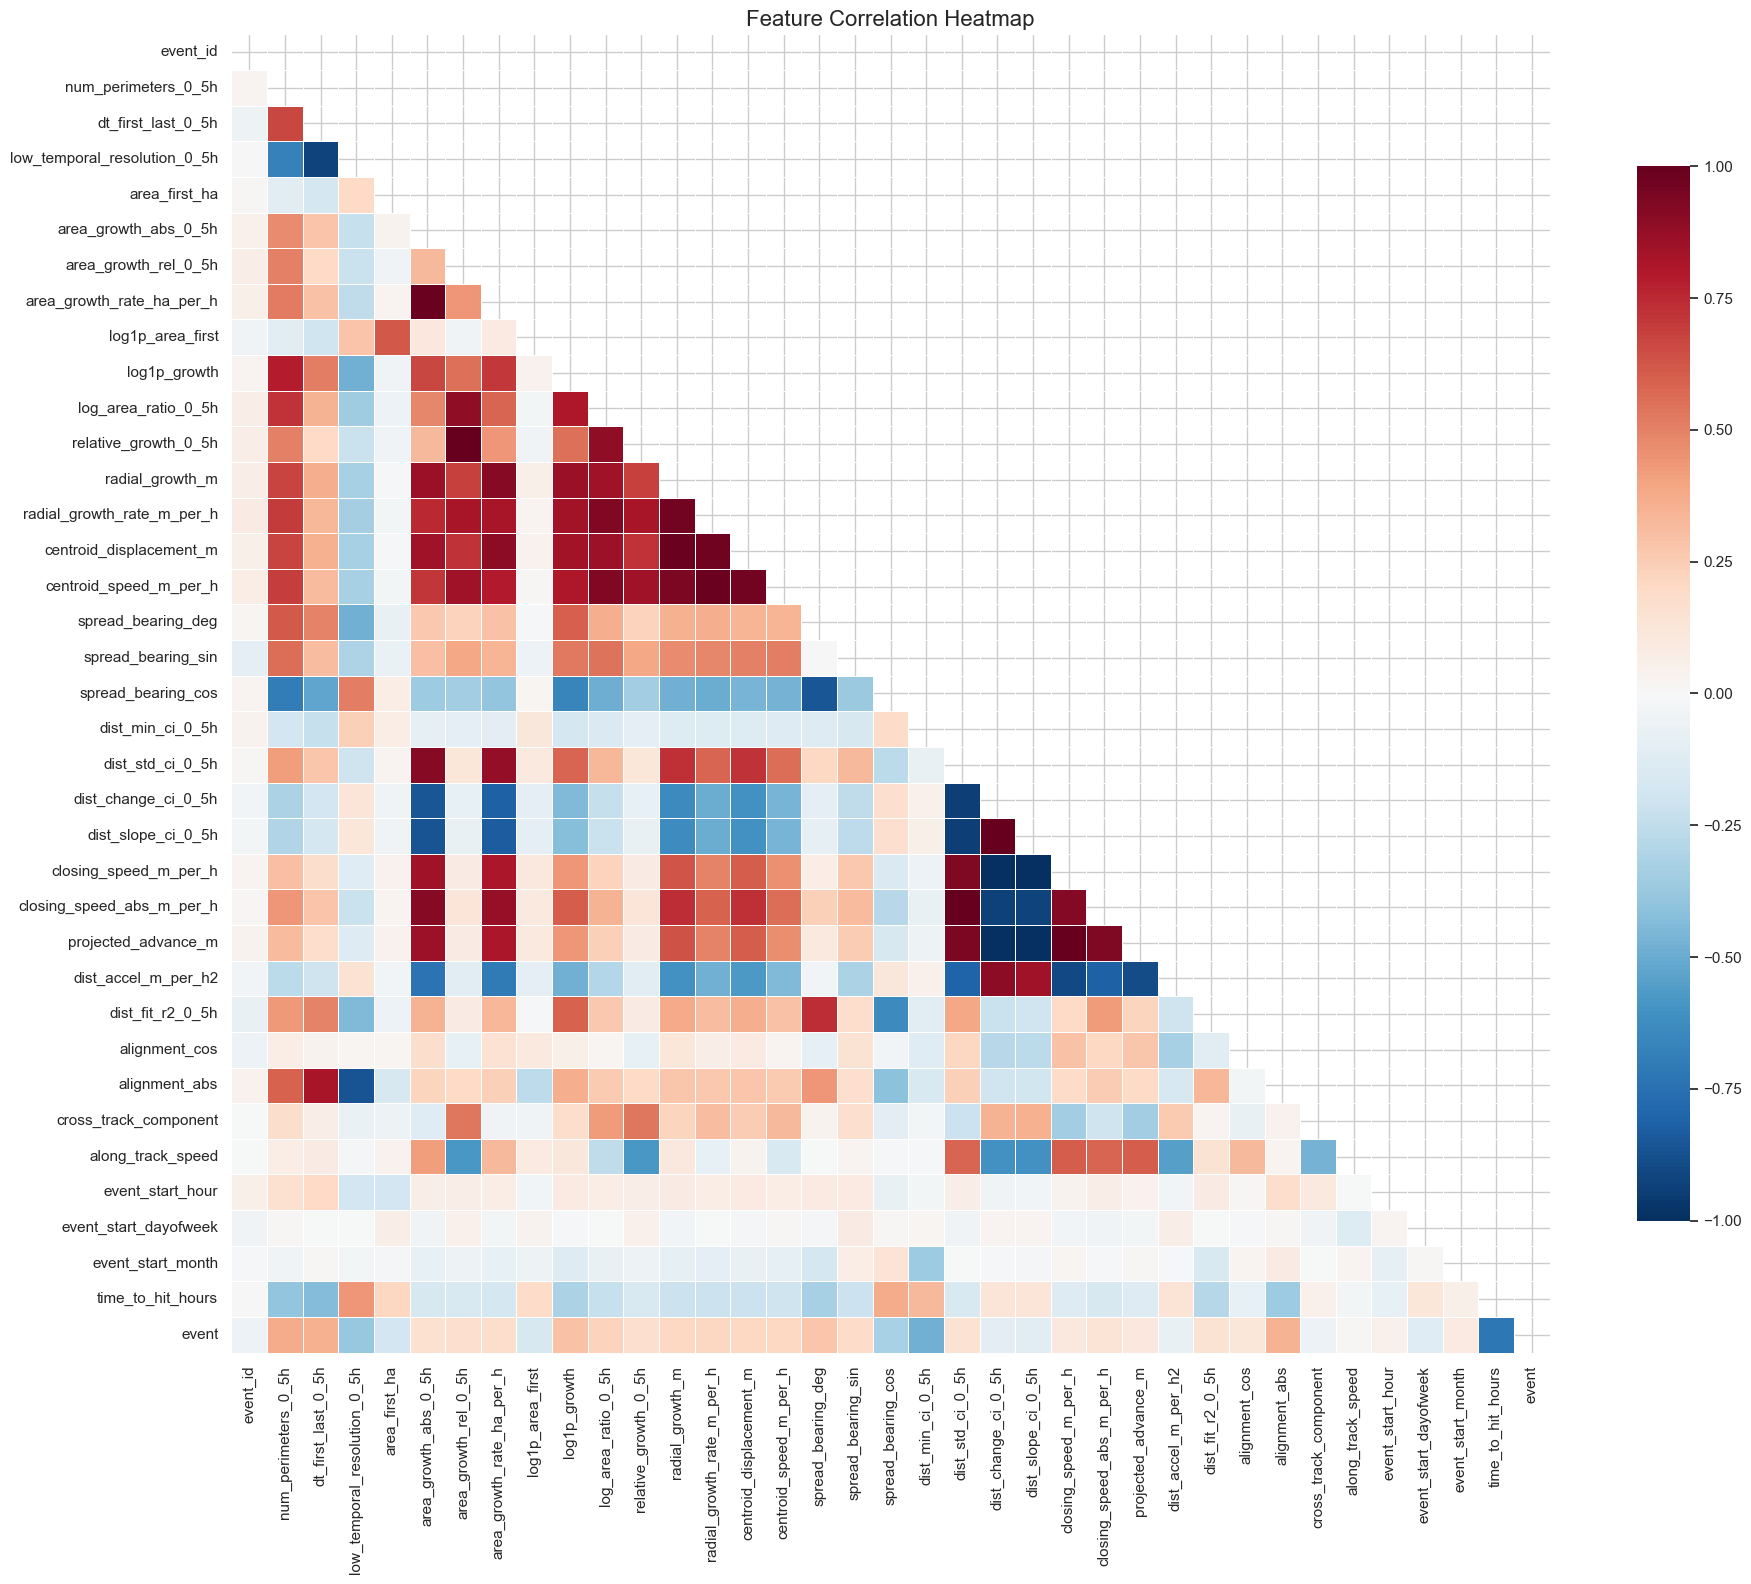

In [13]:
# Full correlation heatmap
numeric_cols = train.select_dtypes(include="number").columns.tolist()
corr = train[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(20, 16))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax, fmt=".2f",
            annot=False, cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Heatmap", fontsize=16)
plt.tight_layout()
save_fig("correlation_heatmap")
plt.show()

In [14]:
# Highly correlated pairs (|r| > 0.9)
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.9:
            high_corr_pairs.append((corr.columns[i], corr.columns[j], round(r, 4)))

high_corr_df = pd.DataFrame(high_corr_pairs, columns=["Feature 1", "Feature 2", "Correlation"])
high_corr_df = high_corr_df.sort_values("Correlation", key=abs, ascending=False)
print(f"Highly correlated pairs (|r| > 0.9): {len(high_corr_df)}")
high_corr_df

Highly correlated pairs (|r| > 0.9): 29


,Feature 1,Feature 2,Correlation
4,area_growth_rel_0_5h,relative_growth_0_5h,1.0000
22,dist_change_ci_0_5h,projected_advance_m,-1.0000
20,dist_change_ci_0_5h,closing_speed_m_per_h,-0.9982
27,closing_speed_m_per_h,projected_advance_m,0.9982
17,dist_std_ci_0_5h,closing_speed_abs_m_per_h,0.9969
25,dist_slope_ci_0_5h,projected_advance_m,-0.9931
19,dist_change_ci_0_5h,dist_slope_ci_0_5h,0.9931
23,dist_slope_ci_0_5h,closing_speed_m_per_h,-0.9931
1,area_growth_abs_0_5h,area_growth_rate_ha_per_h,0.9913
9,radial_growth_m,centroid_displacement_m,0.9891


Saved: ..\reports\figures\correlation_with_target.png


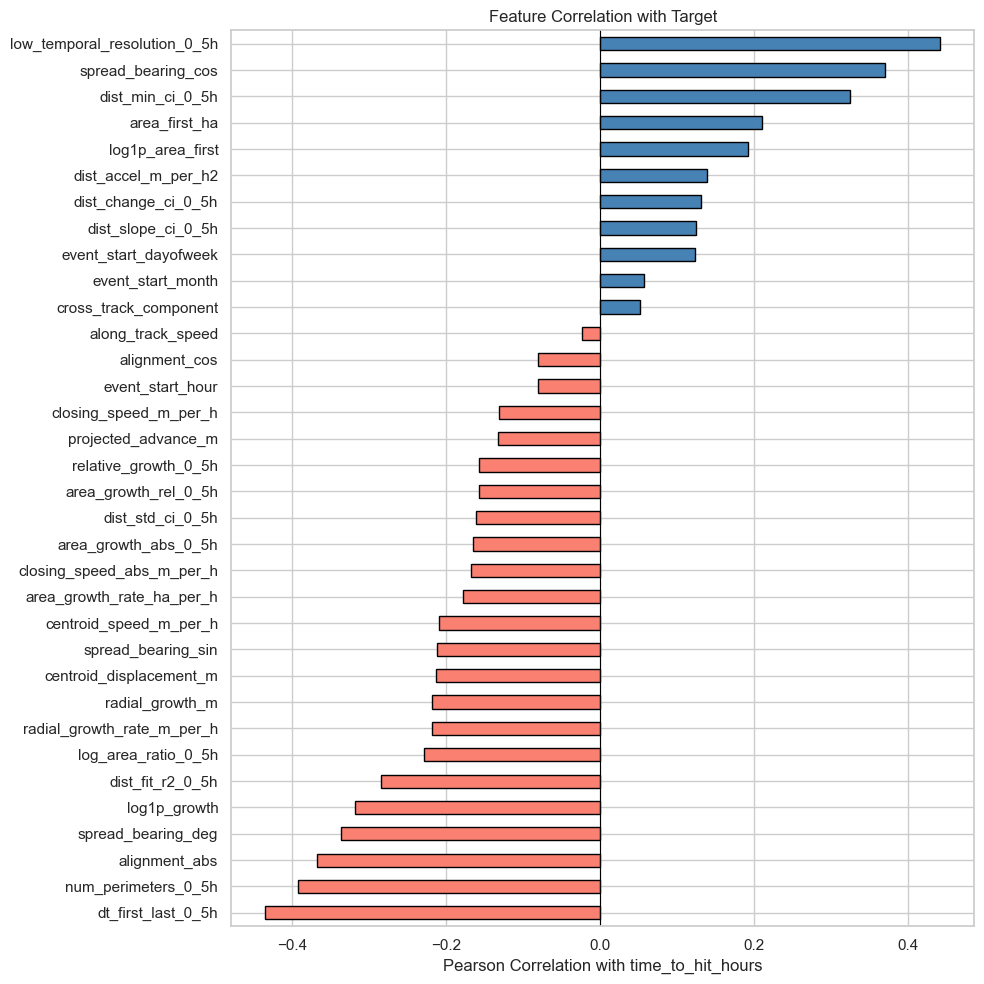

In [15]:
# Correlation with target
target_corr = train[feature_cols].corrwith(train["time_to_hit_hours"]).sort_values()

fig, ax = plt.subplots(figsize=(10, 10))
colors = ["salmon" if v < 0 else "steelblue" for v in target_corr.values]
target_corr.plot(kind="barh", ax=ax, color=colors, edgecolor="black")
ax.set_xlabel("Pearson Correlation with time_to_hit_hours")
ax.set_title("Feature Correlation with Target")
ax.axvline(0, color="black", lw=0.8)
plt.tight_layout()
save_fig("correlation_with_target")
plt.show()

Saved: ..\reports\figures\correlation_with_event.png


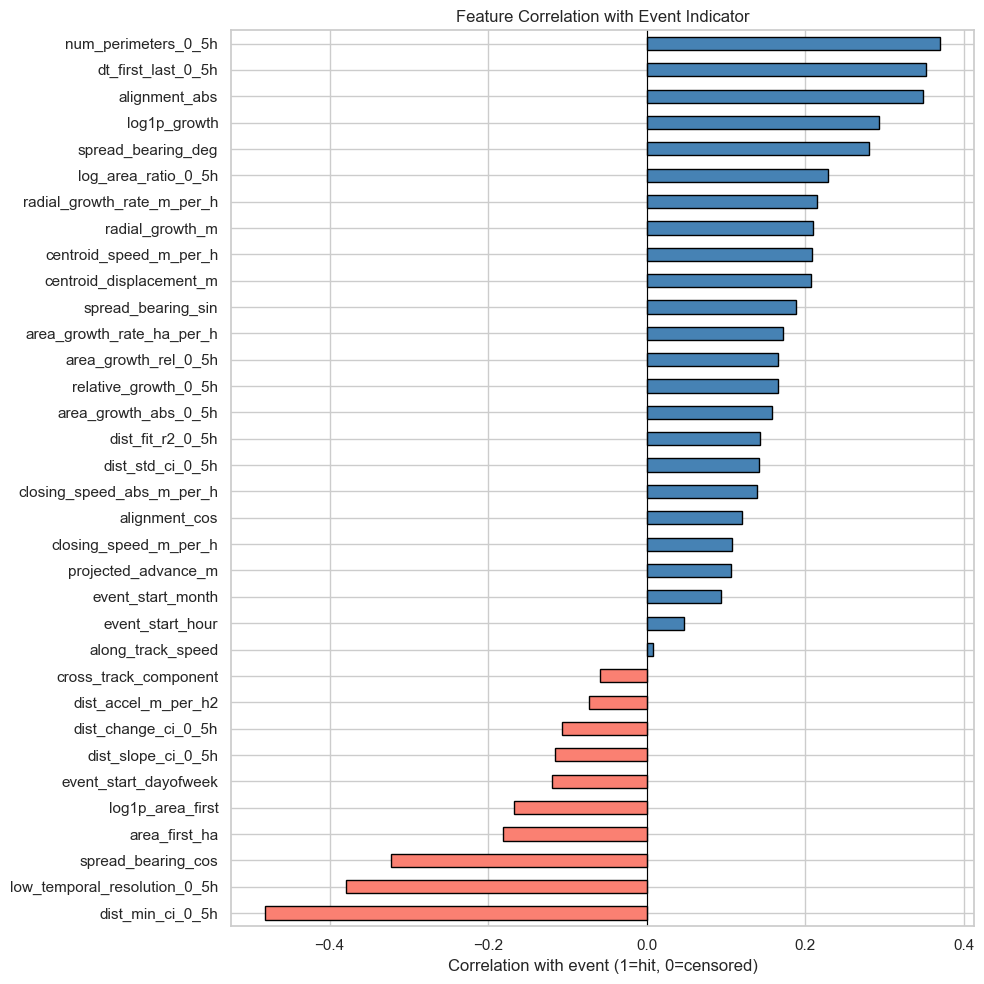

In [16]:
# Point-biserial correlation with event indicator
event_corr = train[feature_cols].corrwith(train["event"]).sort_values()

fig, ax = plt.subplots(figsize=(10, 10))
colors = ["salmon" if v < 0 else "steelblue" for v in event_corr.values]
event_corr.plot(kind="barh", ax=ax, color=colors, edgecolor="black")
ax.set_xlabel("Correlation with event (1=hit, 0=censored)")
ax.set_title("Feature Correlation with Event Indicator")
ax.axvline(0, color="black", lw=0.8)
plt.tight_layout()
save_fig("correlation_with_event")
plt.show()

## 6. Missing Data Patterns

In [17]:
# Null analysis
null_counts = train.isnull().sum()
print(f"Total null values: {null_counts.sum()}")
print(f"\nColumns with nulls:")
nulls_present = null_counts[null_counts > 0]
if len(nulls_present) == 0:
    print("  None — dataset has ZERO null values.")
else:
    print(nulls_present)

Total null values: 0

Columns with nulls:
  None — dataset has ZERO null values.


In [18]:
# Even without nulls, check for implicit missing (zeros, -1, 999, etc.)
print("=== Potential implicit missing values ===")
print(f"\nFeatures where >50% of values are zero:")
high_zero = zero_pct[zero_pct > 0.5]
for col, pct in high_zero.items():
    print(f"  {col}: {pct:.1%} zeros")

print(f"\nFeatures with negative values:")
for col in feature_cols:
    neg_count = (train[col] < 0).sum()
    if neg_count > 0:
        print(f"  {col}: {neg_count} negative values ({neg_count/len(train):.1%})")

=== Potential implicit missing values ===

Features where >50% of values are zero:
  closing_speed_abs_m_per_h: 91.9% zeros
  closing_speed_m_per_h: 91.9% zeros
  projected_advance_m: 91.9% zeros
  dist_change_ci_0_5h: 91.9% zeros
  dist_fit_r2_0_5h: 91.4% zeros
  dist_std_ci_0_5h: 91.4% zeros
  log1p_growth: 89.1% zeros
  spread_bearing_sin: 88.7% zeros
  centroid_displacement_m: 88.7% zeros
  area_growth_rel_0_5h: 88.7% zeros
  centroid_speed_m_per_h: 88.7% zeros
  spread_bearing_deg: 88.7% zeros
  area_growth_rate_ha_per_h: 88.7% zeros
  area_growth_abs_0_5h: 88.7% zeros
  log_area_ratio_0_5h: 88.7% zeros
  radial_growth_rate_m_per_h: 88.7% zeros
  radial_growth_m: 88.7% zeros
  relative_growth_0_5h: 88.7% zeros
  cross_track_component: 88.7% zeros
  along_track_speed: 88.7% zeros
  dist_accel_m_per_h2: 84.2% zeros
  dist_slope_ci_0_5h: 76.5% zeros
  alignment_abs: 72.4% zeros
  dt_first_last_0_5h: 72.4% zeros
  alignment_cos: 72.4% zeros

Features with negative values:
  area_growt

## 7. Train vs Test Distribution Comparison

Saved: ..\reports\figures\train_vs_test_distributions.png


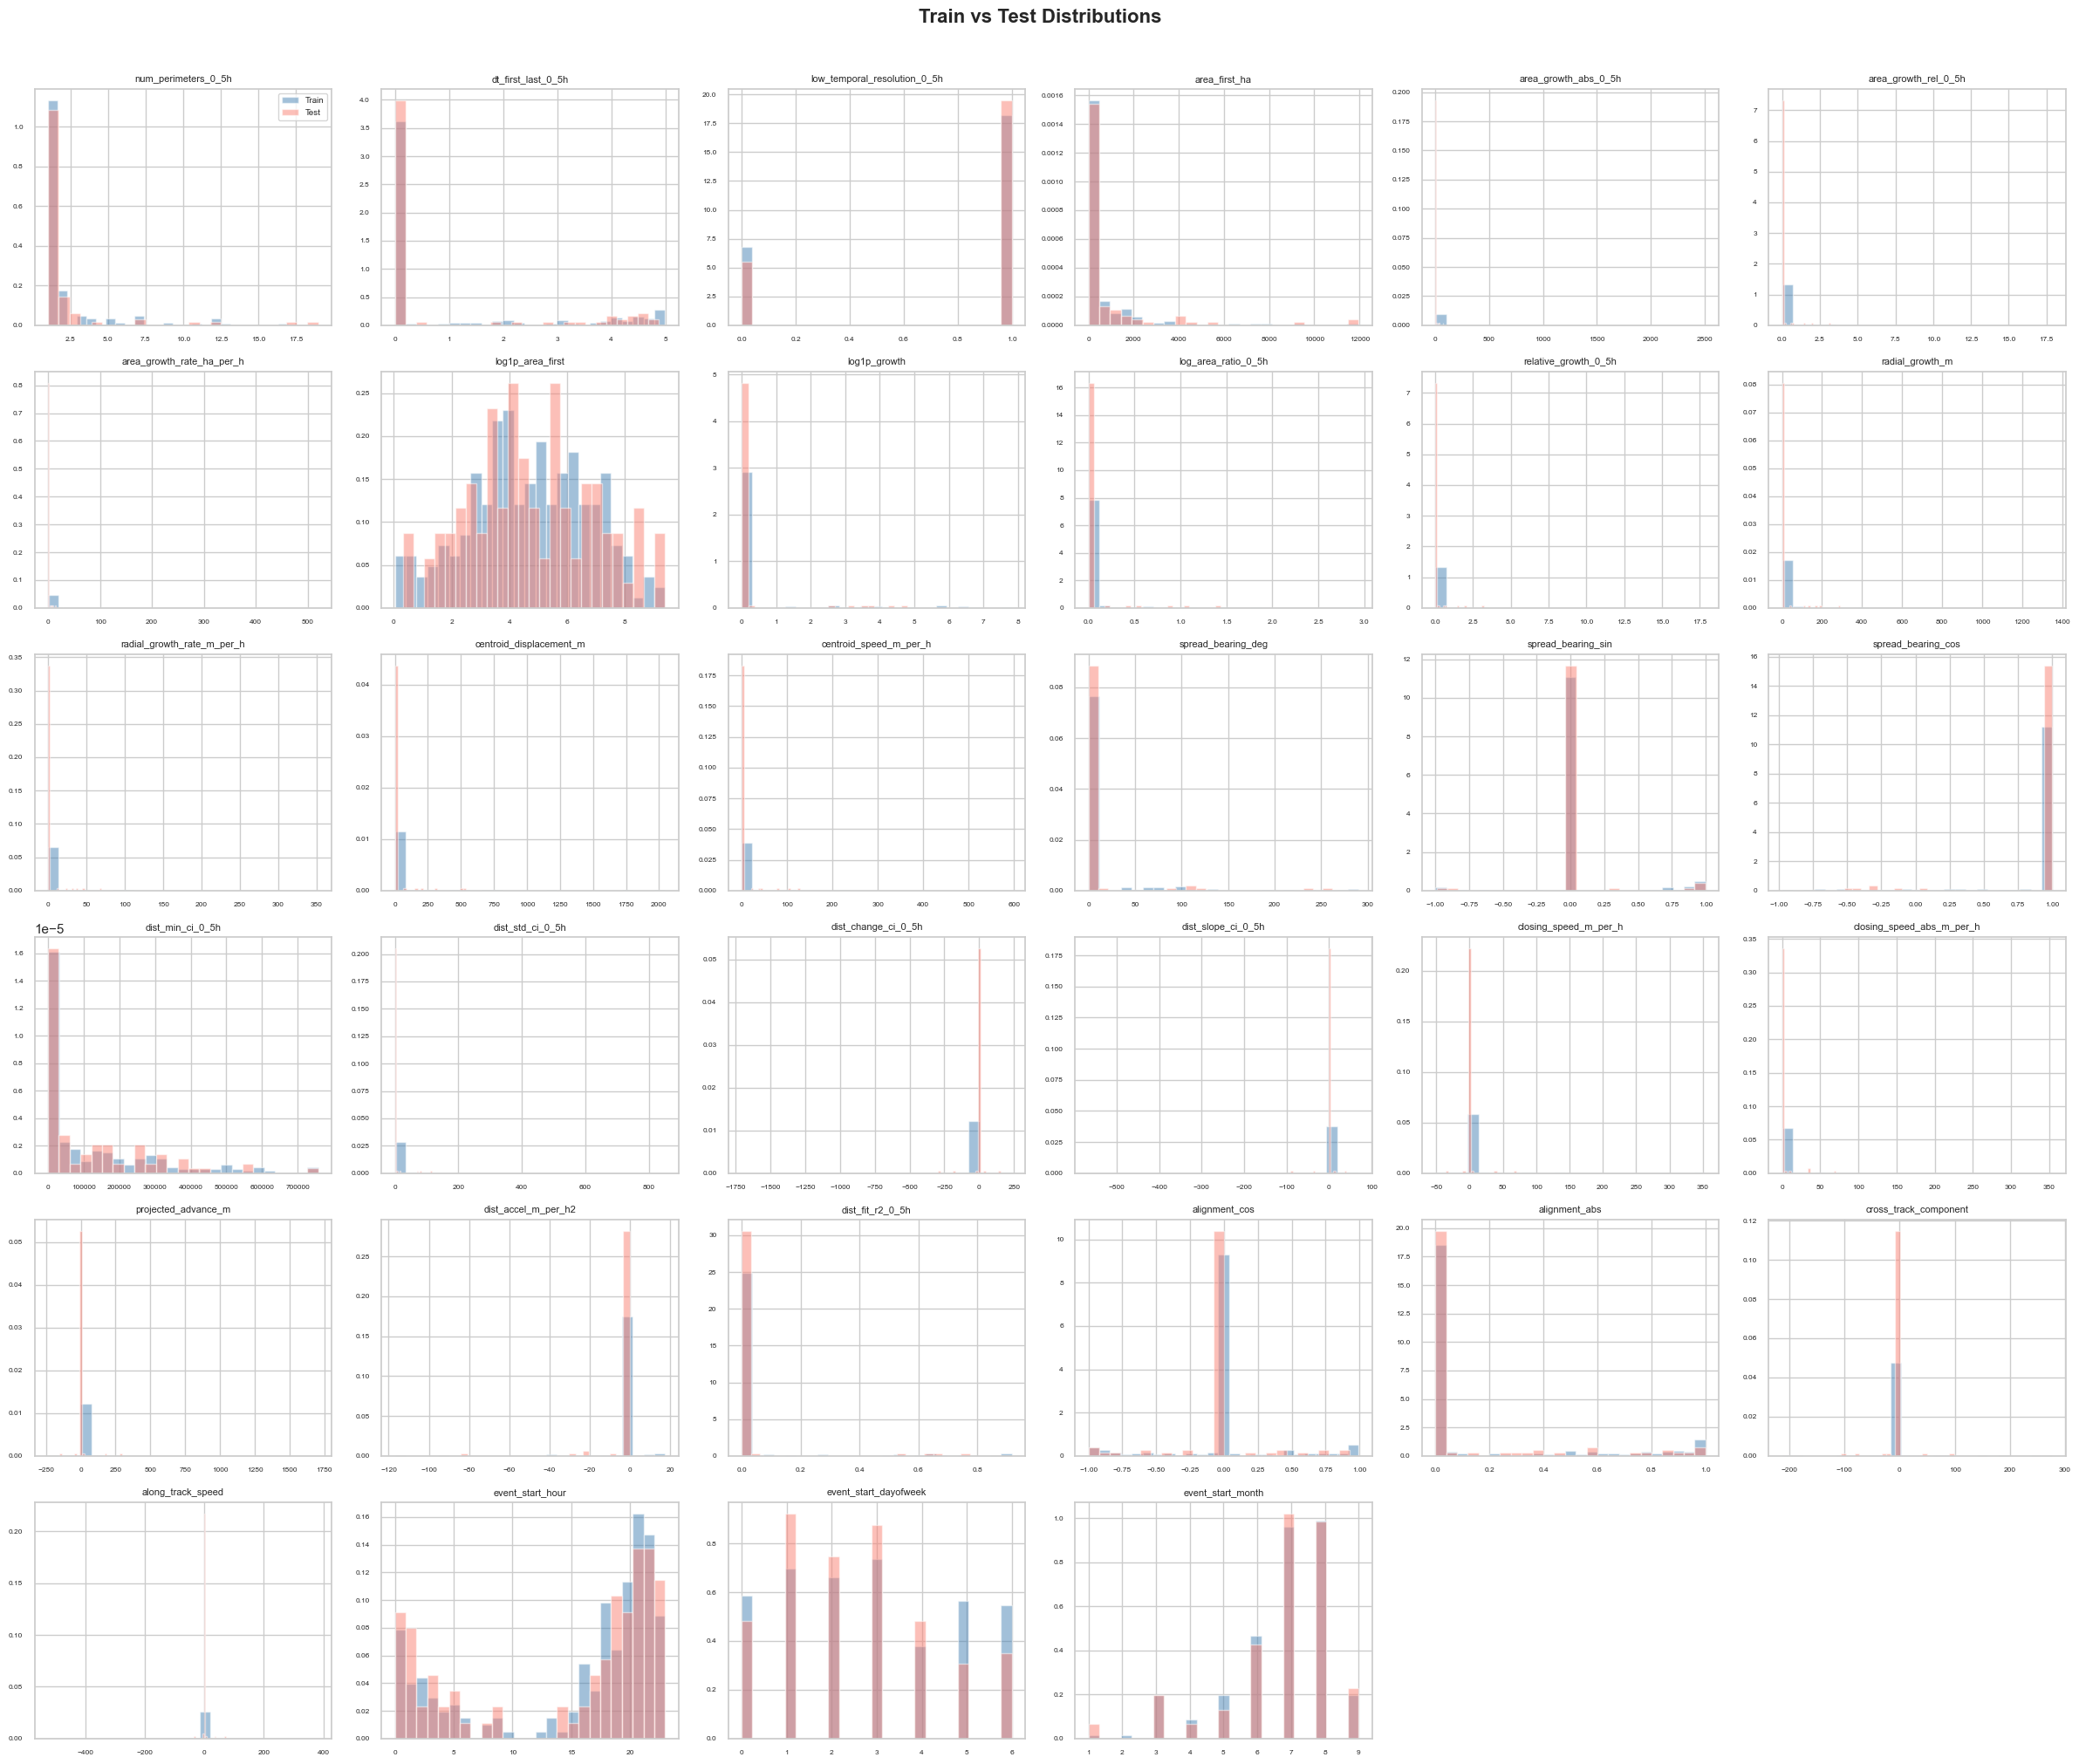

In [19]:
# Compare distributions between train and test
common_cols = [c for c in feature_cols if c in test.columns]

fig, axes = plt.subplots(6, 6, figsize=(24, 20))
axes = axes.flatten()

for i, col in enumerate(common_cols[:36]):
    ax = axes[i]
    ax.hist(train[col], bins=25, alpha=0.5, label="Train", density=True, color="steelblue")
    ax.hist(test[col], bins=25, alpha=0.5, label="Test", density=True, color="salmon")
    ax.set_title(col, fontsize=8)
    ax.tick_params(labelsize=6)
    if i == 0:
        ax.legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Train vs Test Distributions", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
save_fig("train_vs_test_distributions")
plt.show()

## 8. Key Findings

### Dataset Structure
- **221 training samples**, 95 test samples — very small dataset
- **34 features** (all numeric, no categoricals except encoded temporal metadata)
- **Zero null values** in both train and test
- Many features are highly sparse (>50% zeros)

### Target Variable
- `time_to_hit_hours`: continuous, range [0, ~67h] within a 72h window
- `event`: binary — 69 hits (31.2%) vs 152 censored (68.8%)
- **High censoring rate (68.8%)** — most fires never reach the evacuation zone
- Submission requires cumulative probability at 4 horizons (12h, 24h, 48h, 72h)

### Feature Groups
- **Distance features** (9): likely most predictive — distance to evac zone, closing speed
- **Growth features** (10): fire area and growth dynamics
- **Centroid kinematics** (5): fire movement direction and speed
- **Directionality** (4): alignment between fire movement and evac zone
- **Temporal metadata** (3): hour, day of week, month
- **Temporal coverage** (3): perimeter observation quality

### Implications for Modeling
- Small dataset → high variance risk, need robust CV
- High censoring → survival analysis models (Cox PH, RSF) are appropriate
- Sparse features → consider transformations or grouping
- Highly correlated features → feature selection or regularization needed